# Zomata Data Analysis Project 

## Objectives

What type of restaurant do the majority of customers order from?

How many votes has each type of restaurant received from customers?

What are the ratings that the majority of restaurants have received

Zomato has observed that most couples order most of their food online. What is their
average spending on each order?

Which mode (online or offline) has received the maximum rating?

Which type of restaurant received more offline orders, so that Zomato can provide those
customers with some good offers?

## Step no 01 : importing the libraries

In [3]:

import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns



## Step no 02 :  Creating the dataframe

In [4]:
dataframe = pd.read_csv("Zomato data .csv")
dataframe.head()


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


### Changing the data type of columne rate 

In [5]:
def handleRate(value):
    value = str(value).split("/")
    value = value[0]
    return float(value)

dataframe["rate"] = dataframe["rate"].apply(handleRate)
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [12]:
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 KB


## Types of Restruement 

Text(0.5, 0, 'Type of Restaurant')

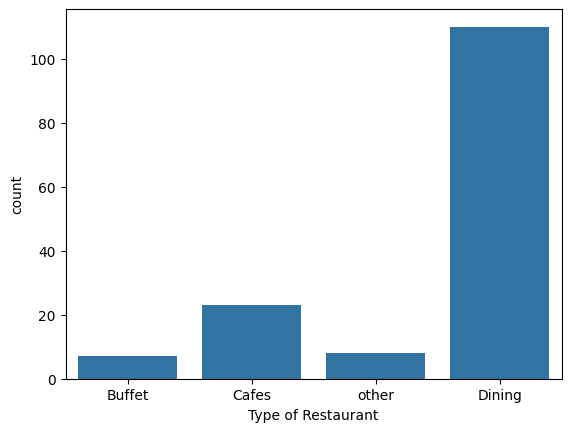

In [15]:
sns.countplot(x=dataframe["listed_in(type)"])
plt.xlabel("Type of Restaurant")

Conclusion : Dining is the best 

How many votes has each type of restaurant received from customers?

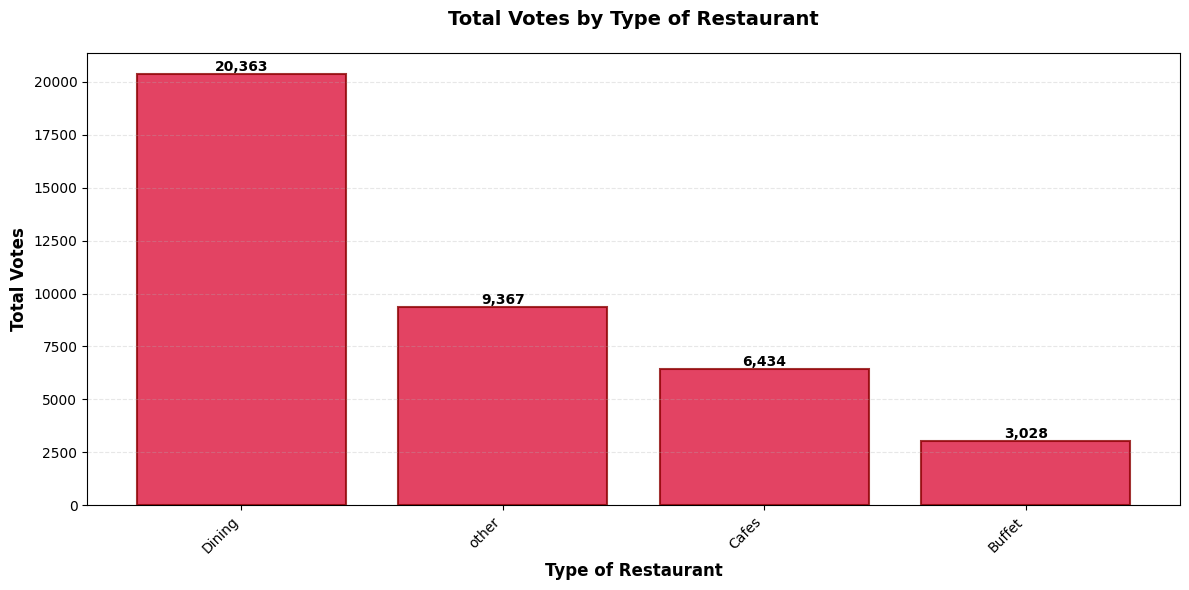

In [24]:
grouped_data = dataframe.groupby("listed_in(type)")["votes"].sum().sort_values(ascending=False)
result = pd.DataFrame({'votes': grouped_data})

# Create a more visually appealing plot
plt.figure(figsize=(12, 6))
bars = plt.bar(result.index, result['votes'], color='crimson', edgecolor='darkred', linewidth=1.5, alpha=0.8)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel("Type of Restaurant", fontsize=12, fontweight='bold')
plt.ylabel("Total Votes", fontsize=12, fontweight='bold')
plt.title("Total Votes by Type of Restaurant", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

conclusion : Dining got more votes 

Which mode (online or offline) has received the maximum rating?

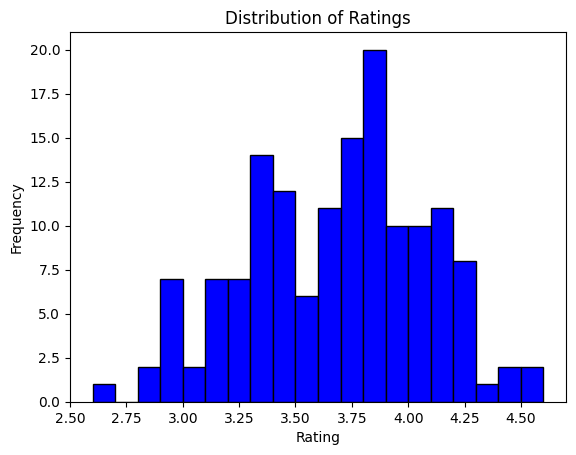

In [23]:
plt.hist(dataframe["rate"], bins=20, color='blue', edgecolor='black')
plt.xlabel("Rating")
plt.ylabel("Frequency")     
plt.title("Distribution of Ratings")
plt.show()

conclusion :  rating 3.5 to 4

Zomato has observed that most couples order most of their food online. What is their
average spending on each order?

In [9]:
online_orders = dataframe[dataframe['online_order'] == 'Yes']
average_spending_couples = online_orders['approx_cost(for two people)'].mean()
print(f"Average spending on each order for couples (online orders): {average_spending_couples:.2f}")

Average spending on each order for couples (online orders): 510.34


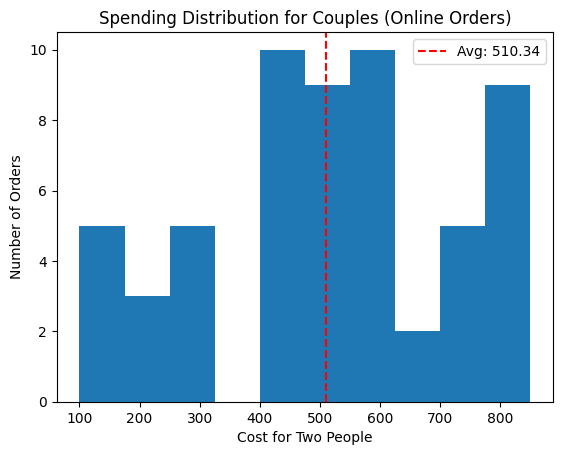

In [11]:
import matplotlib.pyplot as plt

# Simple histogram of spending for online orders (couples)
plt.hist(online_orders['approx_cost(for two people)'], bins=10)
plt.axvline(average_spending_couples, color='red', linestyle='--', label=f'Avg: {average_spending_couples:.2f}')
plt.xlabel('Cost for Two People')
plt.ylabel('Number of Orders')
plt.title('Spending Distribution for Couples (Online Orders)')
plt.legend()
plt.show()

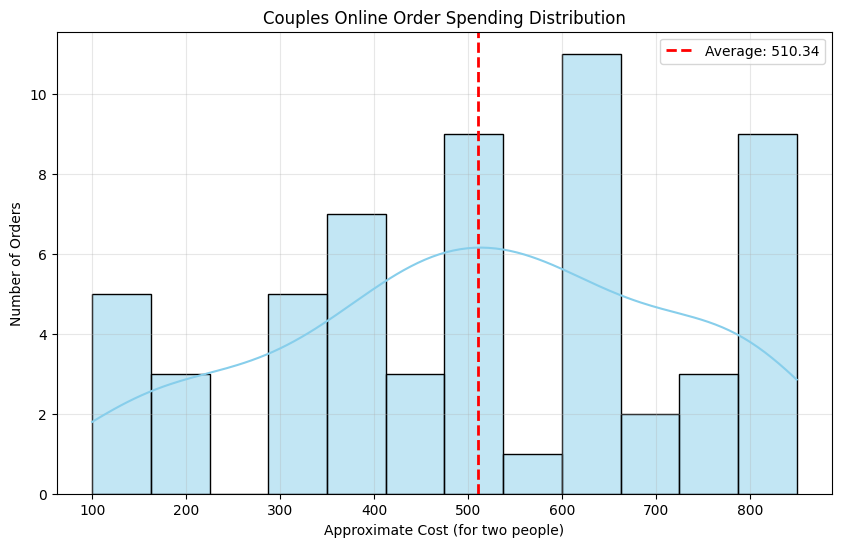

In [ ]:
# Improved plot for couple spending (online orders)
# Use online_orders to align with the question context
coupled_data = online_orders['approx_cost(for two people)'].dropna()

plt.figure(figsize=(10, 6))

# histogram with KDE for better distribution insight
sns.histplot(coupled_data, bins=12, kde=True, color='skyblue', edgecolor='black')
# average line
plt.axvline(average_spending_couples, color='red', linestyle='--', linewidth=2,
            label=f'Average: {average_spending_couples:.2f}')

plt.xlabel('Approximate Cost (for two people)')
plt.ylabel('Number of Orders')
plt.title('Couples Online Order Spending Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Conclusion : average spending  is 310


C:\Users\abdul\AppData\Local\Temp\ipykernel_10804\2162491806.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=max_values.index, y=max_values.values, palette='Blues_d')


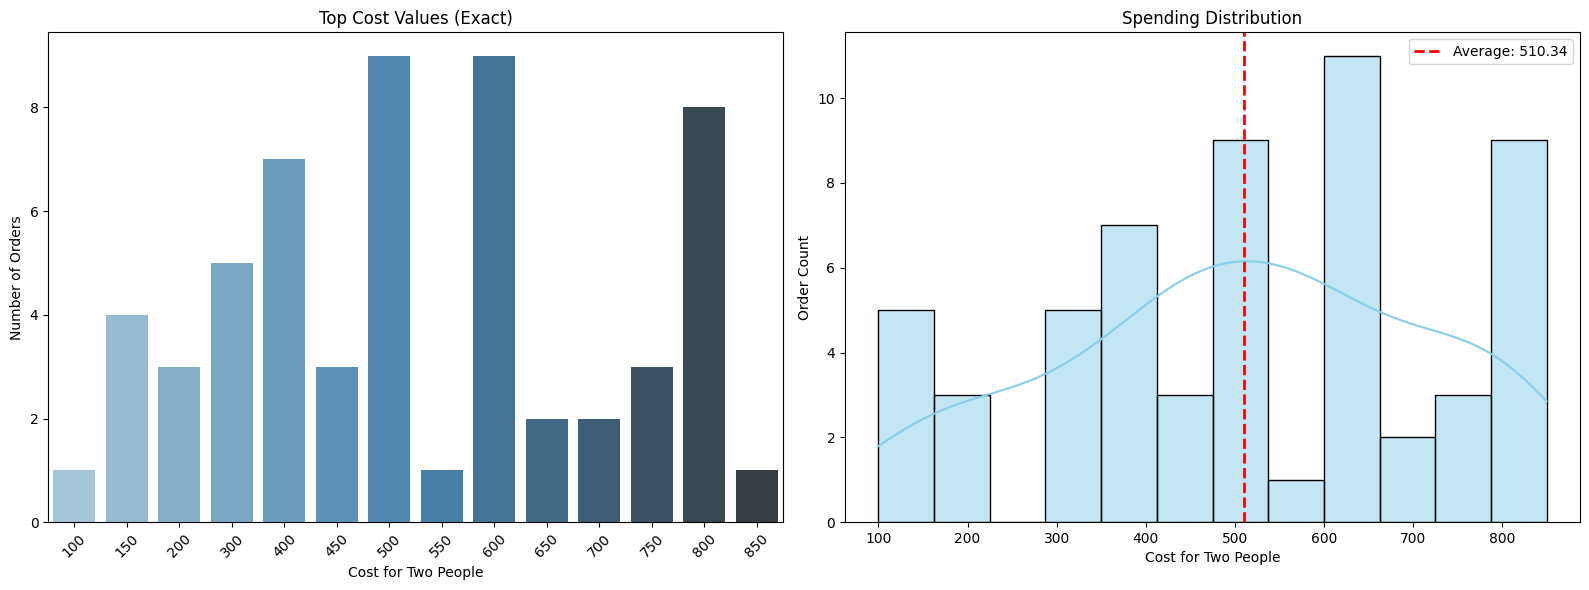

In [20]:
# Side-by-side comparison: exact value counts vs distribution
coupled_data = online_orders['approx_cost(for two people)'].dropna()

plt.figure(figsize=(16, 6))

# 1) Exact value frequency (most useful for seeing the mode like 300)
plt.subplot(1, 2, 1)
max_values = coupled_data.value_counts().nlargest(15)
sns.barplot(x=max_values.index, y=max_values.values, palette='Blues_d')
plt.xticks(rotation=45)
plt.xlabel('Cost for Two People')
plt.ylabel('Number of Orders')
plt.title('Top Cost Values (Exact)')

# 2) Distribution view
plt.subplot(1, 2, 2)
sns.histplot(coupled_data, bins=12, kde=True, color='skyblue', edgecolor='black')
plt.axvline(average_spending_couples, color='red', linestyle='--', linewidth=2,
            label=f'Average: {average_spending_couples:.2f}')
plt.xlabel('Cost for Two People')
plt.ylabel('Order Count')
plt.title('Spending Distribution')
plt.legend()

plt.tight_layout()
plt.show()

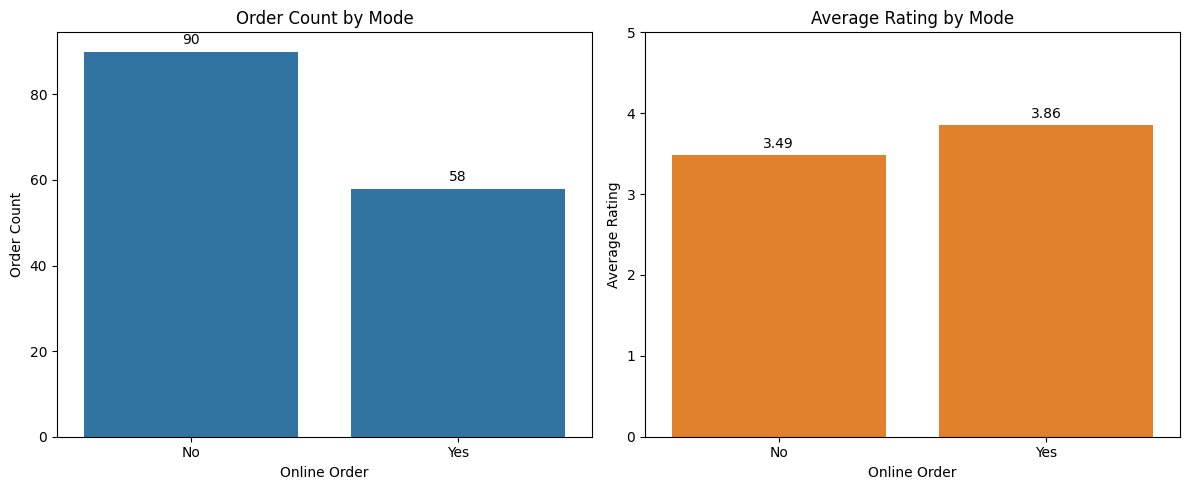

In [28]:
# Updated chart: separate subplots for order count and average rating, easier to interpret
mode_stats = dataframe.groupby('online_order').agg(
    avg_rating=('rate', 'mean'),
    order_count=('rate', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x='online_order', y='order_count', data=mode_stats, ax=axes[0], color='tab:blue')
axes[0].set_title('Order Count by Mode')
axes[0].set_xlabel('Online Order')
axes[0].set_ylabel('Order Count')

sns.barplot(x='online_order', y='avg_rating', data=mode_stats, ax=axes[1], color='tab:orange')
axes[1].set_title('Average Rating by Mode')
axes[1].set_xlabel('Online Order')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(0, 5)

for i, row in mode_stats.iterrows():
    axes[0].text(i, row['order_count'] + 1, int(row['order_count']), ha='center', va='bottom')
    axes[1].text(i, row['avg_rating'] + 0.05, f"{row['avg_rating']:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Rating Distribution by Online Order Availability')

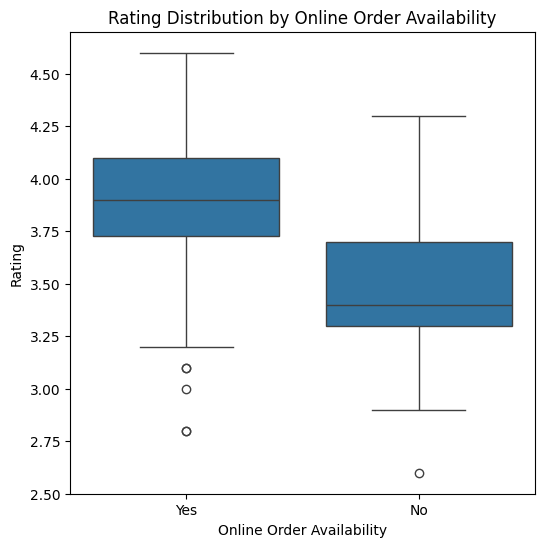

In [30]:
plt.figure(figsize=(6, 6))
sns.boxplot(x="online_order", y="rate", data=dataframe)
plt.xlabel("Online Order Availability") 
plt.ylabel("Rating")
plt.title("Rating Distribution by Online Order Availability")

conclusion : Customers ordering online tend to give higher ratings than offline customers in this dataset, supporting the idea that online ordering is linked to better rated

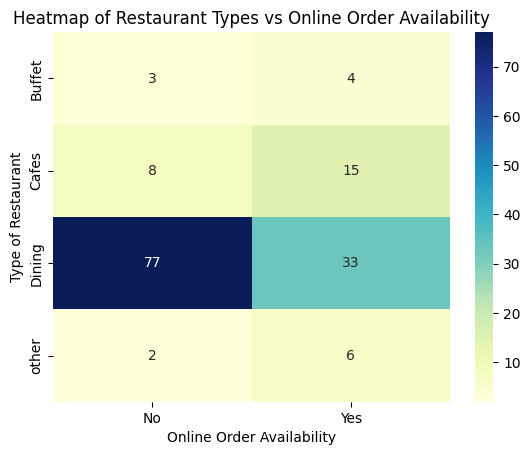

In [31]:
pivot_table = dataframe.pivot_table(index="listed_in(type)", columns="online_order", fill_value=0, aggfunc="size")
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Heatmap of Restaurant Types vs Online Order Availability")
plt.xlabel("Online Order Availability")
plt.ylabel("Type of Restaurant")
plt.show()

Conclusion : Most restaurants are Dining, with a large offline presence but a meaningful online segment; Cafes and “Other” are more likely to offer online ordering proportionally.
This suggests marketing for online adoption might prioritize Dining (because of volume) plus Cafes (because online proportion is higher).